# Import packages

In [1]:
import numpy as np # numerical computing
import matplotlib.pyplot as plt # plotting
import pandas as pd # data handling
from pathlib import Path # file handling
# the code below autoloads new changes (no restart of the kernel needed)
%reload_ext autoreload
%autoreload 2


# Data loading 

In [2]:
df = pd.read_csv('../data/HighSchool2013_proximity_net.csv', header=None, sep=' ')
df = df.rename(columns={0: 'time', 1: 'id1', 2: 'id2', 3: 'class1', 4: 'class2'})
df['time'] = pd.to_datetime(df['time'], unit='s', origin='unix')

In [3]:
df.head()

,time,id1,id2,class1,class2
0,2013-12-02 11:00:20,454,640,MP,MP
1,2013-12-02 11:00:20,1,939,2BIO3,2BIO3
2,2013-12-02 11:00:20,185,258,PC*,PC*
3,2013-12-02 11:00:20,55,170,2BIO3,2BIO3
4,2013-12-02 11:00:20,9,453,PC,PC


[None,
 Text(0, 0.5, '# of pairwise interactions'),
 Text(0.5, 0, 'interaction strength (sum of interation counts)')]

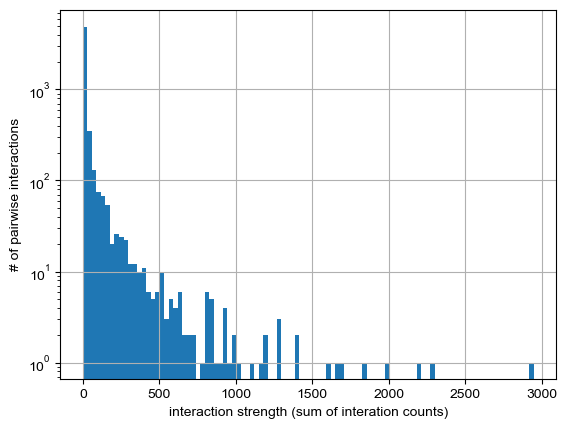

In [4]:
# aggregate all counts to get rough idea of link strength
df_agg = df.groupby(['id1', 'id2'])['class1'].count().rename('counts20s')
f, ax = plt.subplots(1)
df_agg.hist(bins=100, ax=ax)
ax.set(yscale='log',
       ylabel='# of pairwise interactions', 
       xlabel='interaction strength (sum of interation counts)'
       )

# Data preprocessing 

## 2. only consider links ≥ 3 minutes/hour

In [5]:
# now we want to remove to weak connections
# let's say less than 3 minutes per hour is too weak --> we need to define the day and hour
df['day'] = df['time'].apply(lambda x: x.date().day)
df['hour'] = df['time'].apply(lambda x: x.time().hour)
# and groupby over id-columns again, but this time with 'day' and 'hour'
df_agg = df.groupby(['day', 'hour', 'id1', 'id2'])['class1'].count().reset_index().rename(columns={'class1': 'counts20s'})
# filter out the contacts that are shorter than 3 minutes per hour 
df_agg = df_agg[df_agg['counts20s'] >= 15]
# now groupby again over the remaining stronger connections
df_agg = df_agg.groupby(['id1', 'id2'])['counts20s'].sum().reset_index()
df_agg['distance'] = 1 / df_agg['counts20s']

# Data analysis 

## 3. Create a graph with edge weight according to distance 

319


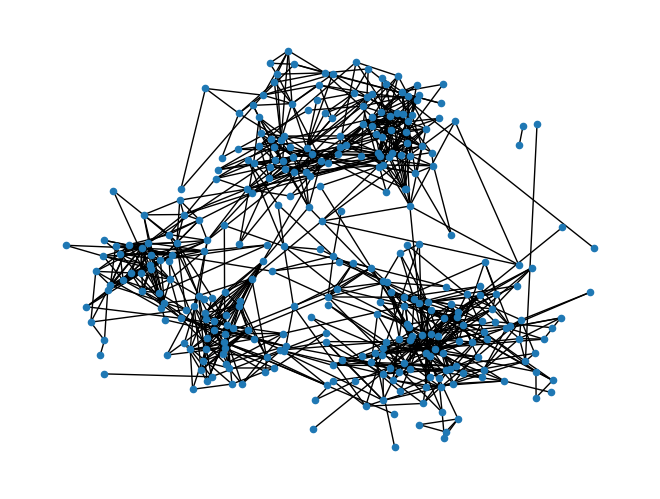

In [6]:
# from these links we create now a network
import networkx as nx
G = nx.Graph()
G.add_weighted_edges_from(df_agg[['id1', 'id2', 'distance']].values)
# and plot it
nx.draw(G, node_size=20)
print(len(G))

315


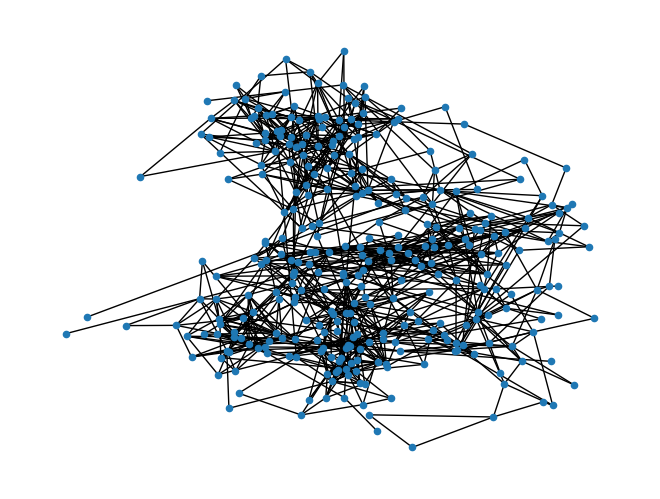

In [7]:
# there are some disconnected nodes --> get the largest connected component of the network
G = G.subgraph(max(nx.components.connected_components(G), key=len)).copy()
# plot again
nx.draw(G, with_labels=False, node_size=20)
print(len(G))

## 4. Create a nice plot with coloring for the classes

In [8]:
# make the plot more colorfull by assigning each node a class, and each class a color
node_to_class = df[['id1', 'class1']].drop_duplicates().set_index('id1').to_dict()['class1']
node_to_class_ = df[['id2', 'class2']].drop_duplicates().set_index('id2').to_dict()['class2']
node_to_class.update(node_to_class_)
classes = df[['class1', 'class2']].stack().unique()
class_to_integer_id = {c: i for i, c in enumerate(classes)}

cmap = plt.cm.get_cmap('tab20', len(classes))
node_color_by_class = [class_to_integer_id[node_to_class[n]] for n in G.nodes()]
node_color_by_class = cmap(node_color_by_class)

/var/folders/f2/4l2m198x30zfsfr7br5dwp7h0000gn/T/ipykernel_22396/3318407004.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', len(classes))


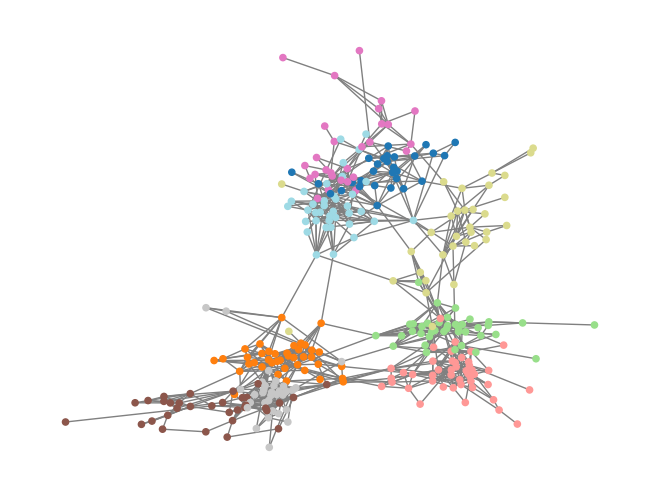

In [9]:
# make the position of the nodes more dependent on the link strength: 
_ = nx.spring_layout(G, seed=2, store_pos_as="pos", iterations=200, weight="weight", method="force")
# plot again
nx.draw(G, node_size=20,
        pos=nx.get_node_attributes(G, 'pos'),
        node_color=node_color_by_class, edge_color='gray')

## 5. Apply a community detection



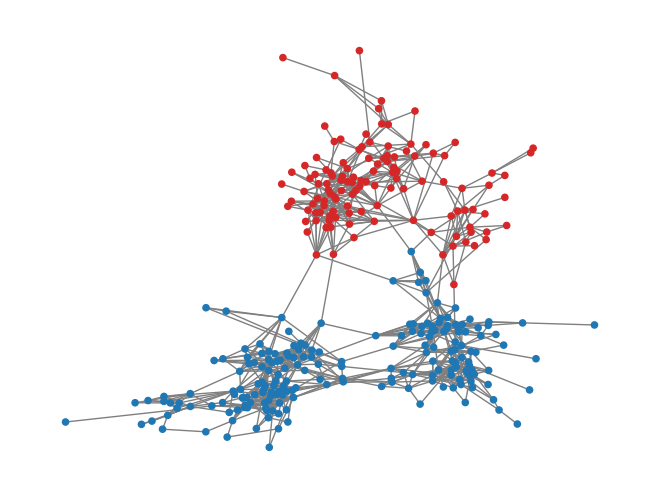

In [10]:
detect = nx.community.girvan_newman(G)
comm = next(detect)
nodes = np.array(list(G.nodes))
node_color_by_comm1 = ['tab:blue' if n in comm[0] else 'tab:red' for n in G.nodes()]
# plot
nx.draw(G, node_size=20,
        pos=nx.get_node_attributes(G, 'pos'),
        edge_color='gray',
        node_color=node_color_by_comm1)

## 6. Apply it again and again

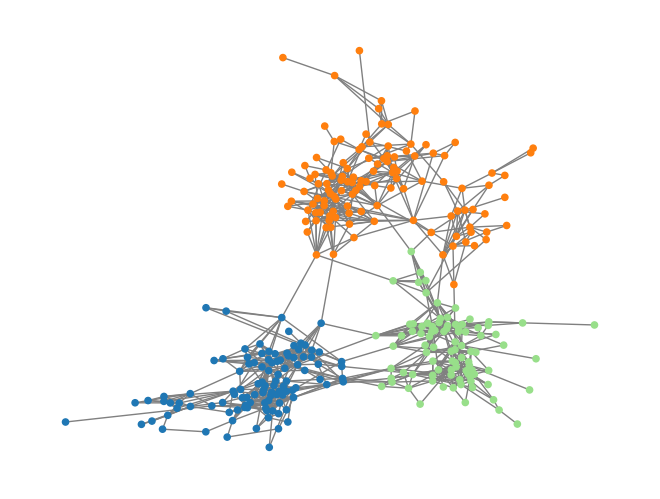

In [11]:
# lets run the algorithm again and split off another community
comm = next(detect)
nodes = np.array(list(G.nodes))
# create a node coloring for 3 colors (we can reuse this for as many colors as needed)
node_to_comm = {}
for n in nodes:
    for i, com in enumerate(comm):
        if n in com:
            node_to_comm[n] = i 
            break
node_color_by_comm2 = cmap([node_to_comm[n] for n in nodes])
# plot
nx.draw(G, node_size=20,
        pos=nx.get_node_attributes(G, 'pos'),
        edge_color='gray',
        node_color=node_color_by_comm2)

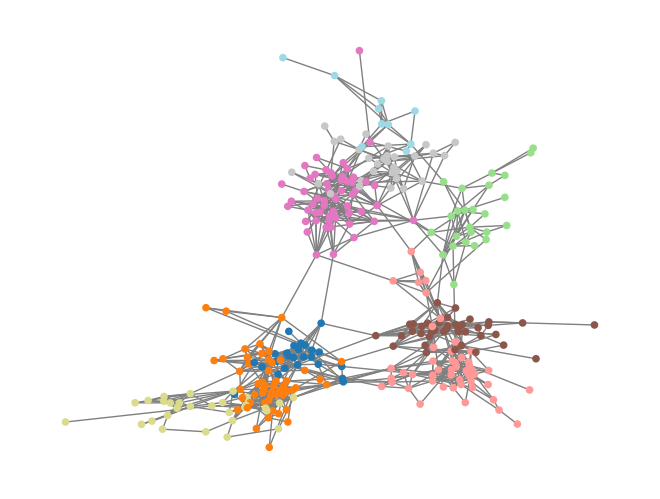

In [12]:
# now apply the algorighm as often until we got as many communities as classes
comm = next(detect)
while len(comm) < len(classes):
    comm = next(detect)
node_to_comm = {}
for n in nodes:
    for i, com in enumerate(comm):
        if n in com:
            node_to_comm[n] = i 
            break
node_color_by_comm_Nclasses = cmap([node_to_comm[n] for n in nodes])
# plot again
nx.draw(G, node_size=20,
        pos=nx.get_node_attributes(G, 'pos'),
        edge_color='gray',
        node_color=node_color_by_comm_Nclasses)

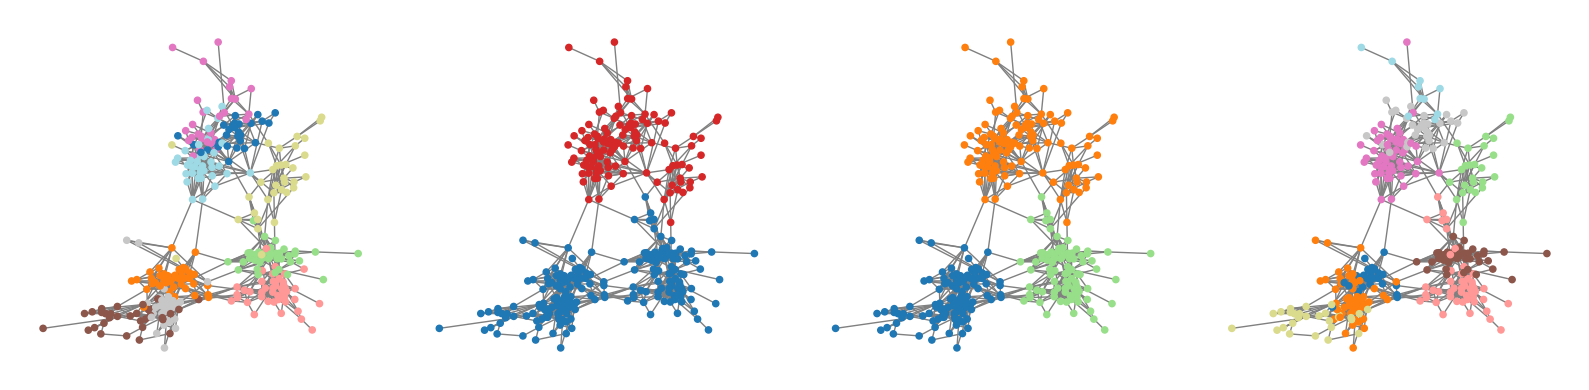

In [13]:
f, axs = plt.subplots(1, 4, sharey=True, figsize=plt.figaspect(1/4))
titles = ['classes', '2 communities', '3 communities', '9=N_classes communities']
for i, node_color in enumerate([node_color_by_class, node_color_by_comm1, node_color_by_comm2, node_color_by_comm_Nclasses]):
    nx.draw(G, node_size=20,
            pos=nx.get_node_attributes(G, 'pos'),
            edge_color='gray',
            node_color=node_color,
            ax=axs[i])
f.tight_layout()